# AICL 3605 - Computer Vision Lab
**Author:** Muhammad Haroon  
**Registration Number:** 23108124  
**Lab Session:** LAB 04: Implementation of Scene enhancement


Image Negative

In [3]:
# Install OpenCV if not already installed
!pip install opencv-python-headless --quiet
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload the image
print("Upload a grayscale image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Step 2: Read the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

Upload a grayscale image:


Saving xray.jpg to xray.jpg


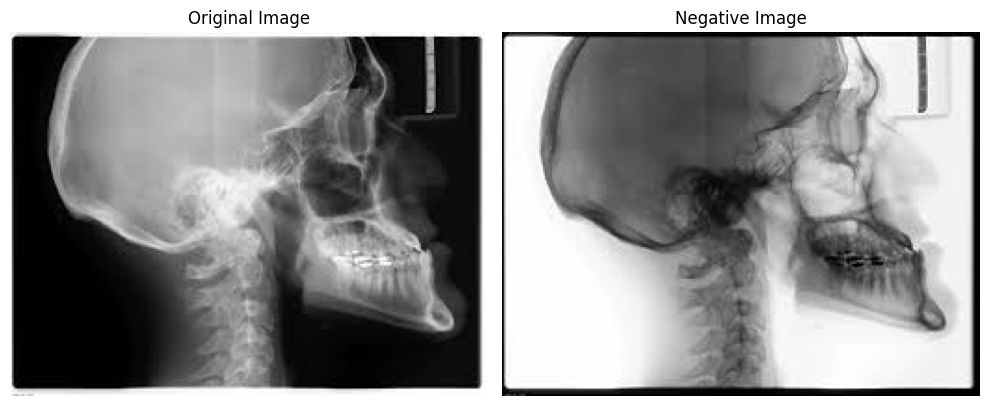

In [4]:
# Step 3: Apply negative transformation
negative = 255 - img

# Step 4: Display results using matplotlib
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(negative, cmap='gray')
plt.title("Negative Image")
plt.axis('off')
plt.tight_layout()
plt.show()

**Code Example 2: Log Transformation**

In [5]:
# Step 1: Upload image
print("Upload a grayscale image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Step 2: Read image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

Upload a grayscale image:


Saving chest.jpg to chest.jpg


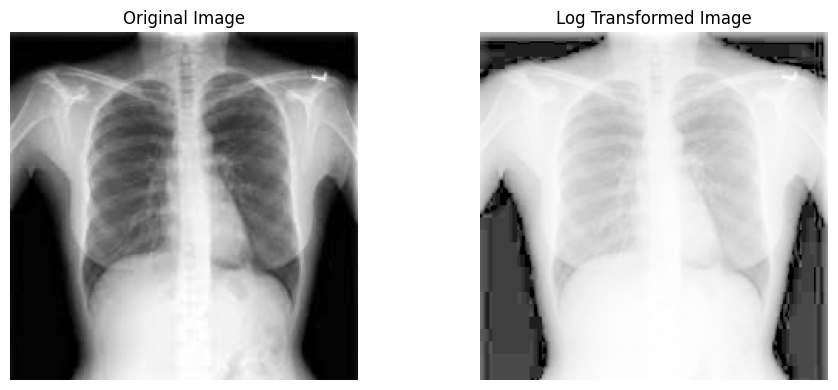

In [6]:
# Step 3: Apply log transformation
img_float = np.float32(img) # Convert to float to avoid log(0) issues
log_transformed = cv2.normalize(np.log1p(img_float), None, 0, 255, cv2.NORM_MINMAX)
log_transformed = np.uint8(log_transformed)

# Step 4: Display original and transformed image
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(log_transformed, cmap='gray')
plt.title("Log Transformed Image")
plt.axis('off')
plt.tight_layout()
plt.show()

**Code Example 3: Gamma Correction**

In [7]:
# Step 1: Upload an image
print("Upload a grayscale or color image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
# Step 2: Read the image (convert to grayscale for simplicity)
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Upload a grayscale or color image:


Saving heathcamera.jpg to heathcamera.jpg


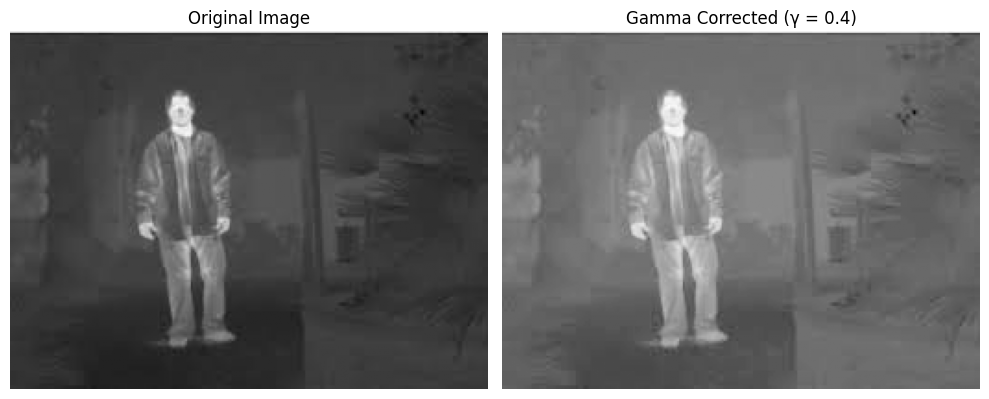

In [8]:
# Step 3: Apply gamma correction
gamma = 0.4 # Use gamma < 1 to brighten, > 1 to darken
gamma_corrected = np.array(255 * (gray / 255) ** gamma, dtype='uint8')

# Step 4: Display original and gamma corrected images
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gamma_corrected, cmap='gray')
plt.title(f"Gamma Corrected (γ = {gamma})")
plt.axis('off')
plt.tight_layout()
plt.show()

**Case Study 1: Medical X-Ray Enhancement (Negative)**

Radiologists often examine X-rays where bones and implants appear dark on a bright background.
Inverting (negative transformation) such images makes bones and structures pop out, especially for
detecting fractures, foreign objects, or implants.

In [9]:
# Upload an X-ray image
print("Upload a grayscale X-ray image:")
uploaded = files.upload()
path = list(uploaded.keys())[0]
# Read in grayscale
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

Upload a grayscale X-ray image:


Saving bone.webp to bone.webp


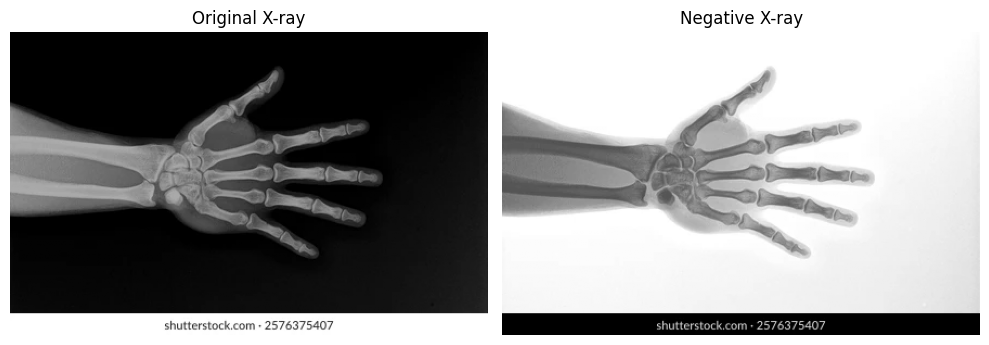

In [10]:
# Apply negative transformation
negative = 255 - img

# Display the images
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original X-ray")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(negative, cmap='gray')
plt.title("Negative X-ray")
plt.axis('off')
plt.tight_layout()
plt.show()

**Case Study 2: Astronomical Image Enhancement (Log Transform)**

Astronomers analyzing deep space photos often face the challenge of seeing faint stars or galaxies next
to very bright ones. Log transformation enhances low-intensity (dim) regions without letting bright
areas dominate the image.

In [11]:
# Upload a telescopic image
print("Upload a grayscale astronomical image:")
uploaded = files.upload()
path = list(uploaded.keys())[0]

# Read in grayscale
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

Upload a grayscale astronomical image:


Saving Screenshot 2026-03-28 223012.png to Screenshot 2026-03-28 223012.png


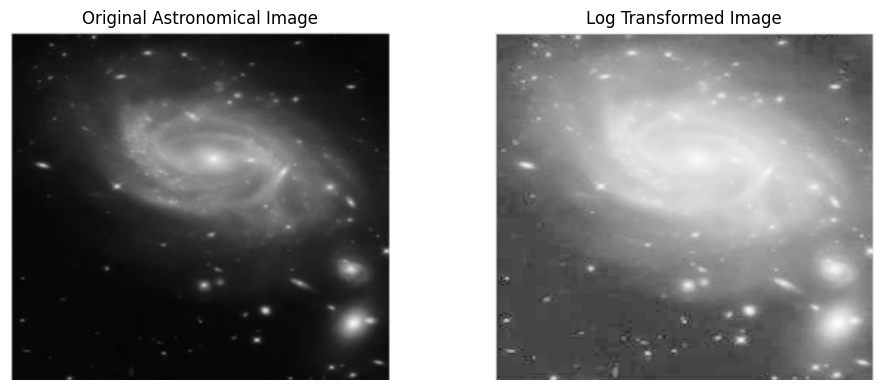

In [12]:
# Apply log transformation
img_float = np.float32(img)
log_transformed = cv2.normalize(np.log1p(img_float), None, 0, 255, cv2.NORM_MINMAX)
log_transformed = np.uint8(log_transformed)

# Display images
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Astronomical Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(log_transformed, cmap='gray')
plt.title("Log Transformed Image")
plt.axis('off')
plt.tight_layout()
plt.show()

**Case Study 4: License Plate Enhancement in Low-Light Surveillance**

Surveillance cameras often capture low-light or poorly illuminated images at night. Important details
like license plates appear too dark or faded, making recognition difficult.
Goal: Enhance low-light images using contrast stretching to make license plates readable.

In [13]:
# Step 1: Upload an image
print("Upload a night-time surveillance image:")
uploaded = files.upload()
path = list(uploaded.keys())[0]

# Step 2: Read and convert to grayscale
img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Upload a night-time surveillance image:


Saving Screenshot 2026-03-28 223206.png to Screenshot 2026-03-28 223206.png


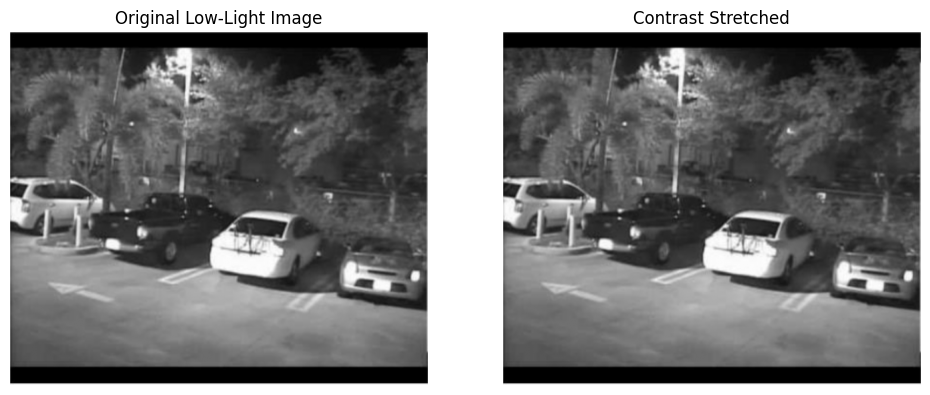

In [14]:
# Step 3: Apply contrast stretching
min_val = np.min(gray)
max_val = np.max(gray)
stretched = ((gray - min_val) / (max_val - min_val) * 255).astype('uint8')

# Step 4: Display result
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Low-Light Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(stretched, cmap='gray')
plt.title("Contrast Stretched")
plt.axis('off')
plt.tight_layout()
plt.show()

**Case Study 5: Old Document Enhancement for OCR**

Old scanned documents (e.g., historical records or faded forms) often have uneven lighting or faded
ink, making it hard for OCR (Optical Character Recognition) to extract text.
Goal: Enhance contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization) for better
readability and OCR accuracy.

In [15]:
# Step 1: Upload a scanned document
print("Upload a scanned grayscale document:")
uploaded = files.upload()
path = list(uploaded.keys())[0]
# Step 2: Read and convert to grayscale
img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Upload a scanned grayscale document:


Saving images.jpg to images.jpg


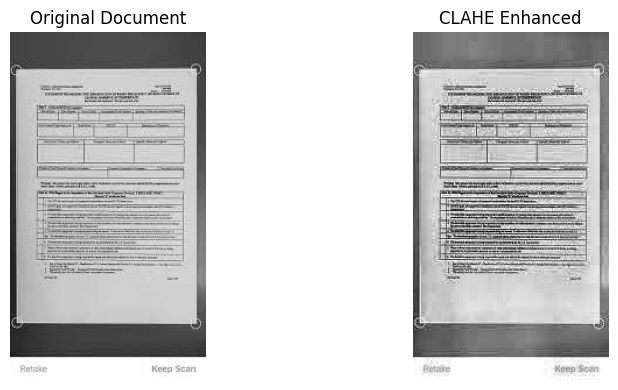

In [16]:
# Step 3: Apply CLAHE (Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)

# Step 4: Display result
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Document")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced")
plt.axis('off')
plt.tight_layout()
plt.show()